# 09 — `Wavelet`: Morlet continuous wavelet transform

Builds a bank of complex Morlet kernels at log- or linear-spaced
centre frequencies and convolves the input with each. Output is
`(phase, amplitude, freqs)` per (B, C, F, T). Compared to
`Spectrogram`'s fixed STFT window, Morlet adapts the window length
per carrier — better time resolution at high freq, better frequency
resolution at low.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import chirp

import scitex_nn

fs, duration = 500, 2.0
seq_len = int(fs * duration)
t = np.arange(seq_len) / fs
sig = chirp(t, f0=5, t1=t[-1], f1=60).astype(np.float32)
x = torch.from_numpy(sig).view(1, 1, -1)

## Morlet scalogram with instantaneous-frequency overlay

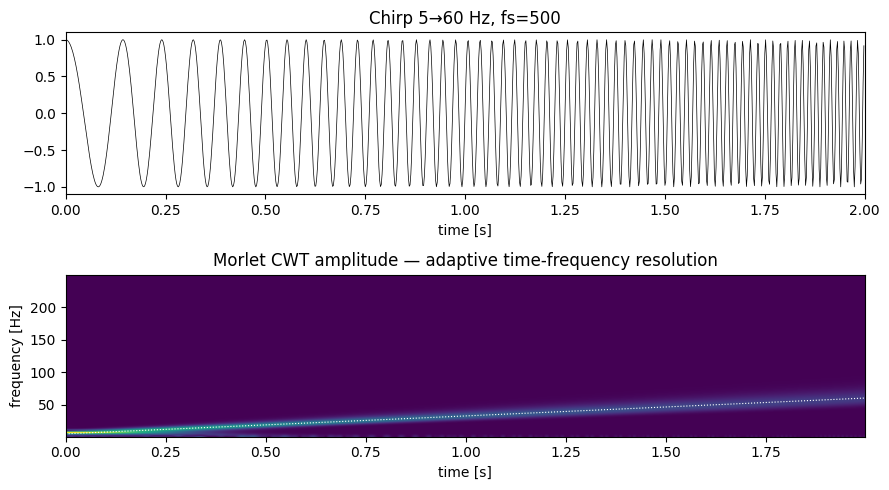

In [2]:
wav = scitex_nn.Wavelet(samp_rate=fs, freq_scale="linear", out_scale="linear")
_, amp, freqs = wav(x)
amp = amp.squeeze().numpy()
freqs = freqs.squeeze().numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
axes[0].plot(t, sig, "k", lw=0.5)
axes[0].set_xlim(0, duration)
axes[0].set_xlabel("time [s]")
axes[0].set_title(f"Chirp 5→60 Hz, fs={fs}")

axes[1].imshow(
    amp,
    aspect="auto",
    origin="lower",
    extent=(0, float(t[-1]), float(freqs[0]), float(freqs[-1])),
    cmap="viridis",
)
axes[1].plot(t, np.linspace(5, 60, seq_len), color="white", ls=":", lw=0.8)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("frequency [Hz]")
axes[1].set_title("Morlet CWT amplitude — adaptive time-frequency resolution")
fig.tight_layout()
plt.show()